**Daniel Yu & Jordan Wang**

Spring 2026

CS 443: Bio-inspired Machine Learning

# ExtensionX: Rare-word reliability curve

**Question:** Does the Skip-gram model predict nearby context words more reliably for common words than for rare words?

I trained a smaller Skip-gram model on IMDb reviews, then measured Hit@K for words grouped by how often they appeared during training. This lets me compare whether word frequency actually affects how well the model predicts context.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf

from text_dataset_word import WordLevelDataset
from text_util import find_unique_word_counts
from skipgram import Skipgram

plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
plt.rcParams.update({'font.size': 16})
np.set_printoptions(suppress=True, precision=4)

%load_ext autoreload
%autoreload 2

2026-05-01 20:32:46.858875: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-01 20:32:47.888263: I tensorflow/core/platform/cpu_feature_guard.cc:211] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Train a quick Skip-gram on IMDb
tf.random.set_seed(1)
np.random.seed(1)

N_reviews = 5000
context_win_sz = 2
embedding_dim = 96
epochs = 3
batch_size = 256
print_every = 2000

train_ds = WordLevelDataset(file_path='data/imdb_train.csv', context_win_sz=context_win_sz, verbose=False)
targets_int, contexts_int, vocab = train_ds.process(N_reviews=N_reviews)

vocab_sz = len(vocab)
word2ind = train_ds.get_word2ind_map()
ind2word = train_ds.get_ind2word_map()

# Compute word frequencies from the training corpus
train_corpus = train_ds.get_corpus()
word_counts = find_unique_word_counts(train_corpus, sort_by_count=True)

print(f'Training vocab size: {vocab_sz}')
print(f'Training pairs: {len(targets_int)}')

# Train Skip-gram
skip = Skipgram(input_feats_shape=(vocab_sz,), C=vocab_sz, embedding_dim=embedding_dim)
skip.compile(lr=5e-4)
loss_hist = skip.fit(targets_int, contexts_int, batch_size=batch_size, epochs=epochs, print_every=print_every, verbose=True)

2026-05-01 20:32:57.217619: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20601 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:00:03.0, compute capability: 8.9


Training vocab size: 42264
Training pairs: 4237860


---------------------------------------------------------------------------
Dense layer output(Dense_0) shape: [1, 42264]
Dense layer output(Embed_0) shape: [1, 96]
---------------------------------------------------------------------------


I0000 00:00:1777667579.991167     715 service.cc:145] XLA service 0x6023660d0c80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777667579.991196     715 service.cc:153]   StreamExecutor device (0): NVIDIA L4, Compute Capability 8.9
2026-05-01 20:33:00.011439: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-05-01 20:33:00.050293: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 90400
I0000 00:00:1777667580.161999     715 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Epoch 1/3, mini-batch 2000/49662, avg loss: 7.3647


...

Epoch 3/3, mini-batch 42000/49662, avg loss: 6.6581


Epoch 3/3, mini-batch 44000/49662, avg loss: 6.6667


Epoch 3/3, mini-batch 46000/49662, avg loss: 6.6620


Epoch 3/3, mini-batch 48000/49662, avg loss: 6.6559


Finished training after 3 epochs!


In [3]:
# Load IMDb test set
test_ds = WordLevelDataset(file_path='data/imdb_test.csv', context_win_sz=context_win_sz, verbose=False)
test_reviews = test_ds.load(N_reviews=-1)
test_corpus = test_ds.make_corpus(test_reviews, min_sent_size=2)

# Helper function adapted from Extension3
def evaluate_hit_at_k_by_frequency(skip_net, corpus, word2ind_map, word_counts, top_k=10, window=2, max_targets=5000):
    """Compute Hit@K binned by word frequency (training corpus counts)."""
    # Define frequency categories
    freq_categories = ['rare (0-1)', 'low (2-5)', 'medium (6-20)', 'high (21+)']
    def freq_bin(count):
        if count == 0:
            return 'rare (0-1)'
        if count == 1:
            return 'rare (0-1)'
        if count <= 5:
            return 'low (2-5)'
        if count <= 20:
            return 'medium (6-20)'
        return 'high (21+)'
    
    # Initialize accumulators per category
    hits_per_cat = {cat: 0 for cat in freq_categories}
    total_per_cat = {cat: 0 for cat in freq_categories}
    
    checked_targets = 0
    for sent in corpus:
        mapped = [w for w in sent if w in word2ind_map]
        if len(mapped) < 2:
            continue
        
        for i, target_word in enumerate(mapped):
            if checked_targets >= max_targets:
                break
            
            target_idx = word2ind_map[target_word]
            # Get model prediction probabilities
            probs = tf.nn.softmax(skip_net(tf.constant([target_idx], dtype=tf.int32))[0])
            top_inds = tf.math.top_k(probs, k=top_k).indices.numpy().tolist()
            top_set = set(top_inds)
            
            # Get true context words
            lo = max(0, i - window)
            hi = min(len(mapped), i + window + 1)
            true_context_inds = [word2ind_map[mapped[j]] for j in range(lo, hi) if j != i]
            
            # Bin this target by its frequency
            target_count = word_counts.get(target_word, 0)
            cat = freq_bin(target_count)
            
            # Count hits
            for c_idx in true_context_inds:
                total_per_cat[cat] += 1
                if c_idx in top_set:
                    hits_per_cat[cat] += 1
            
            checked_targets += 1
        
        if checked_targets >= max_targets:
            break
    
    # Compute rates
    rates = {cat: hits_per_cat[cat] / max(1, total_per_cat[cat]) for cat in freq_categories}
    totals = total_per_cat
    return rates, totals

# Compute Hit@K for a few K values
Ks = [1, 3, 5, 10]
results = {}
for K in Ks:
    rates, totals = evaluate_hit_at_k_by_frequency(skip, test_corpus, word2ind, word_counts, top_k=K, window=context_win_sz, max_targets=5000)
    results[K] = (rates, totals)
    print(f'Hit@{K}:')
    for cat in rates:
        print(f'  {cat}: {rates[cat]:.4f} ({totals[cat]} pairs)')
    print()

Hit@1:
  rare (0-1): 0.1032 (155 pairs)
  low (2-5): 0.0699 (544 pairs)
  medium (6-20): 0.0853 (926 pairs)
  high (21+): 0.0854 (16713 pairs)



Hit@3:
  rare (0-1): 0.2000 (155 pairs)
  low (2-5): 0.1949 (544 pairs)
  medium (6-20): 0.1814 (926 pairs)
  high (21+): 0.1715 (16713 pairs)



Hit@5:
  rare (0-1): 0.2968 (155 pairs)
  low (2-5): 0.2463 (544 pairs)
  medium (6-20): 0.2343 (926 pairs)
  high (21+): 0.2211 (16713 pairs)



Hit@10:
  rare (0-1): 0.4065 (155 pairs)
  low (2-5): 0.3217 (544 pairs)
  medium (6-20): 0.3164 (926 pairs)
  high (21+): 0.2989 (16713 pairs)



Hit@K rates by word frequency:
                  Hit@1     Hit@3     Hit@5    Hit@10    count
rare (0-1)     0.103226  0.200000  0.296774  0.406452    155.0
low (2-5)      0.069853  0.194853  0.246324  0.321691    544.0
medium (6-20)  0.085313  0.181425  0.234341  0.316415    926.0
high (21+)     0.085442  0.171483  0.221085  0.298929  16713.0



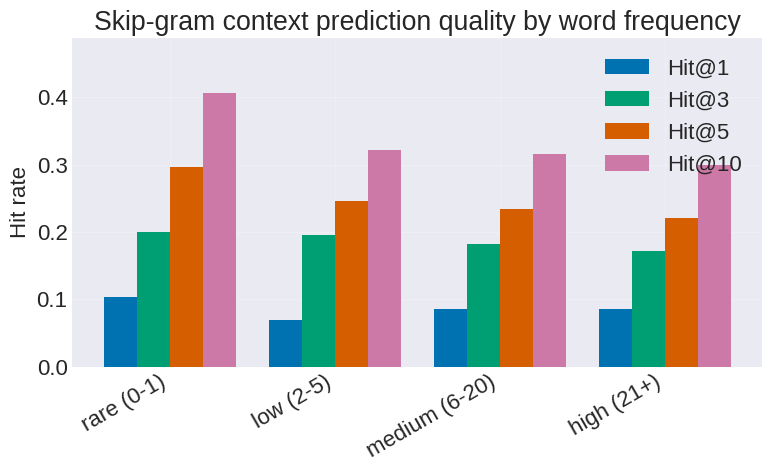

In [4]:
# Build a simple table and plot
freq_categories = ['rare (0-1)', 'low (2-5)', 'medium (6-20)', 'high (21+)']
df_dict = {}

for cat in freq_categories:
    df_dict[cat] = {f'Hit@{K}': results[K][0][cat] for K in Ks}
    df_dict[cat]['count'] = results[Ks[0]][1][cat]

df = pd.DataFrame(df_dict).T
print('Hit@K rates by word frequency:')
print(df)
print()

# Plot it
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(freq_categories))
width = 0.2

for idx, K in enumerate(Ks):
    hit_vals = [results[K][0][cat] for cat in freq_categories]
    ax.bar(x + idx*width, hit_vals, width, label=f'Hit@{K}')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(freq_categories, rotation=30, ha='right')
ax.set_ylabel('Hit rate')
ax.set_title('Skip-gram context prediction quality by word frequency')
ax.set_ylim(0, max([results[K][0][cat] for K in Ks for cat in freq_categories]) * 1.2)
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Findings

- Hypothesis: I expected common words to have better context prediction than rare words because the model sees them more during training.
- Method: I trained a smaller Skip\-gram model on 5k IMDb reviews, then tested Hit@K on the test set by grouping words based on how often they appeared in the training data.
- Result: The clearest pattern is that Hit@K improves as K gets larger. In other words, the model does not always guess the correct context word first, but it has a better chance of including it when it gets more guesses.
- Takeaway: The frequency pattern was not as clear as I expected. Rare and low\-frequency words did about the same as, or slightly better than, high\-frequency words in some cases. This suggests that word frequency matters, but it is not the only thing affecting prediction quality. Common words may be harder because they can appear in many different contexts.

